## Using the polish dataset to predict future corporate bankruptcy cases using financial indicators

### About the polish dataset

This dataset is designed for bankruptcy prediction of Polish companies. It includes financial ratios derived from companies' financial statements, aiming to predict whether a company will go bankrupt within a specific future timeframe. The data was collected from the Emerging Markets Information Service (EMIS), covering:

- Bankrupt companies: Analyzed from 2000 to 2012.
- Non-bankrupt companies: Evaluated from 2007 to 2013.

Each entry represents a company's financial data for a particular year, along with a label indicating whether the company went bankrupt after a certain number of years.

🗂️ Dataset Structure: 1-Year to 5-Year Forecasts

The dataset is divided into five subsets, each corresponding to a different forecasting horizon:
- 1st Year: Financial data from the first year, predicting bankruptcy after 5 years.
- 2nd Year: Financial data from the second year, predicting bankruptcy after 4 years.
- 3rd Year: Financial data from the third year, predicting bankruptcy after 3 years.
- 4th Year: Financial data from the fourth year, predicting bankruptcy after 2 years.
- 5th Year: Financial data from the fifth year, predicting bankruptcy after 1 year.

Each subset contains:
- Financial ratios: 64 variables (e.g., net profit/total assets, total liabilities/total assets).
- Class label: Indicates whether the company went bankrupt (1) or not (0) after the specified period.

**This structure allows for analyzing how early financial indicators can predict bankruptcy over different time horizons.**

🏢 Company Details
The dataset includes a total of 10,503 instances (financial statements), with:

- 495 representing bankrupted companies.
- 10,008 representing companies that did not go bankrupt in the forecasting period.

However, the dataset does not provide specific company names or identifiers. This anonymization is standard practice to protect company confidentiality.

🔍 Purpose and Usage
The primary goal of this dataset is to facilitate research and development of models for predicting company bankruptcy. Researchers and practitioners can use it to:

- Develop and test classification algorithms.
- Analyze the impact of financial ratios on bankruptcy risk.
- Explore the effectiveness of early warning systems over different time horizon

### Step 1: Aggregate year 1 to year 5 datasets
- We read each CSV file into a DataFrame, assign appropriate column names, and add a YearsToBankruptcy column to indicate the forecasting horizon.
- All DataFrames are then concatenated into a single DataFrame for further processing.

In [18]:
import pandas as pd
import numpy as np
import os

# Define the paths to the CSV files
file_paths = {
    '1stYear': '../datasets/raw/1year.csv',
    '2ndYear': '../datasets/raw/2year.csv',
    '3rdYear': '../datasets/raw/3year.csv',
    '4thYear': '../datasets/raw/4year.csv',
    '5thYear': '../datasets/raw/5year.csv'
}

# Initialize an empty list to store DataFrames
dataframes = []

for label, path in file_paths.items():
    # Load each CSV file WITH header
    df = pd.read_csv(path)
    
    # Rename 'Bankrupt?' column to 'Bankrupt'
    df.rename(columns={'Bankrupt?': 'Bankrupt'}, inplace=True)
    
    # Add a column indicating years to bankruptcy (1 to 5)
    df['YearsToBankruptcy'] = int(label[0])  # Extract the number from the label
    
    dataframes.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes, ignore_index=True)

# Save the clean combined dataset
combined_df.to_csv("../datasets/clean/combined_polish_bankruptcy_data.csv", index=False)

# Display head
combined_df.head()


,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,equity / total assets,...,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs / total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities * 365) / sales,sales / short-term liabilities,sales / fixed assets,Bankrupt,YearsToBankruptcy
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


### Step 2: Handling Missing Values
The dataset contains missing values. We'll handle them using mean imputation.
We use SimpleImputer from scikit-learn to replace missing values with the mean of each column.

In [9]:
from sklearn.impute import SimpleImputer

# Separate features and target
features = combined_df.drop(columns=['Bankrupt'])
target = combined_df['Bankrupt']

# Initialize the imputer
imputer = SimpleImputer(strategy='mean')

# Fit and transform the features
features_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

# Combine imputed features with the target
processed_df = features_imputed.copy()
processed_df['Bankrupt'] = target.values


### Step 3: Model training
- We'll train a Random Forest classifier to predict bankruptcy.
- We split the data into training and testing sets, ensuring the class distribution is maintained (stratify=y).
- A Random Forest classifier is trained and evaluated using standard metrics.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Define features and target
X = processed_df.drop(columns=['Bankrupt'])
y = processed_df['Bankrupt']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      8263
           1       0.90      0.33      0.48       418

    accuracy                           0.97      8681
   macro avg       0.93      0.66      0.73      8681
weighted avg       0.96      0.97      0.96      8681

Confusion Matrix:
[[8247   16]
 [ 281  137]]


### Step 4: Evaluation and Analysis 

**Model Performance:**
- The classification report and confusion matrix provide insights into the model's performance, including precision, recall, and F1-score for both classes (bankrupt and non-bankrupt).

**Feature Importance:**
- Understanding which features contribute most to the prediction can be valuable.

**This plot highlights the top 10 features that the Random Forest model considers most important for predicting bankruptcy.**



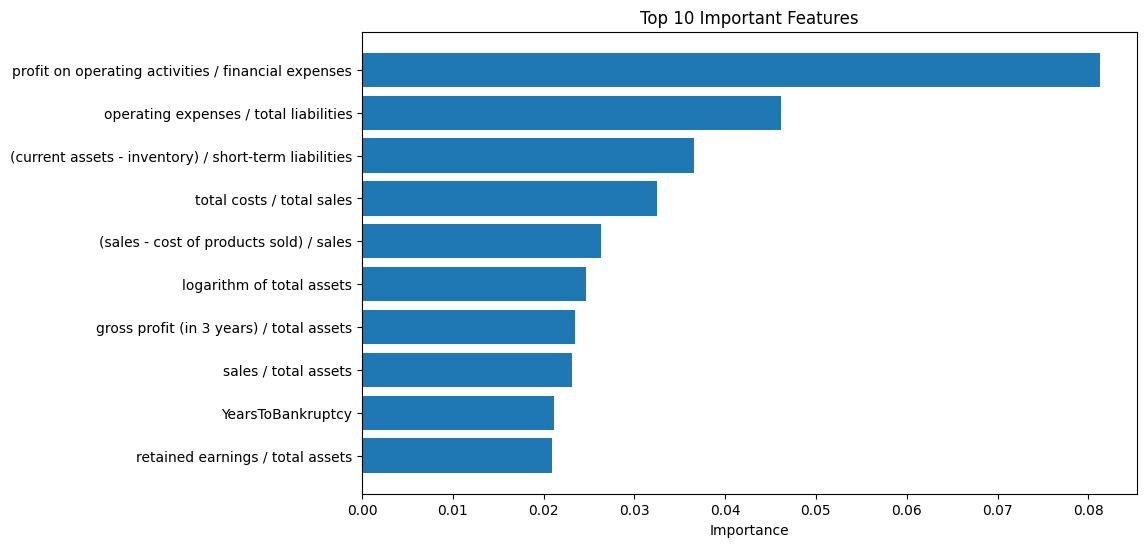

In [11]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_classifier.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()


### Conclusive results for the Random Forest Classifier Model:

📊 1. Model Performance Summary

📄 Classification Report

| **Metric**   | **Non-Bankrupt (0)** | **Bankrupt (1)** |
|--------------|-----------------------|------------------|
| Precision    | 0.97                  | 0.90             |
| Recall       | 1.00                  | 0.33             |
| F1-score     | 0.98                  | 0.48             |
| Support      | 8263                  | 418              |


- Overall Accuracy: 97%
- Macro F1-score: 0.73
- Imbalance in classes: The model performs very well on non-bankrupt companies but struggles with bankrupt ones — recall = 0.33 means it misses 2 out of 3 actual bankruptcies.


📄 Confusion Matrix

### Confusion Matrix

|               | Predicted: 0 | Predicted: 1 |
|---------------|--------------|--------------|
| **Actual: 0** | 8247         | 16           |
| **Actual: 1** | 281          | 137          |

- Only 137 bankrupt firms were correctly predicted.
- 281 bankrupt firms were missed (false negatives).


📊 Your plot shows the top 10 features contributing to bankruptcy prediction. Notable ones include:

| **Feature**                                             | **Interpretation**                                      |
|----------------------------------------------------------|----------------------------------------------------------|
| profit on operating activities / financial expenses      | High predictive power: indicates financial efficiency    |
| operating expenses / total liabilities                   | Operational efficiency vs debt burden                    |
| (current assets - inventory) / short-term liabilities    | Liquidity measure: ability to cover short-term debt      |
| logarithm of total assets                                | Captures company size                                    |
| YearsToBankruptcy                                        | Model leverages time horizon effectively                 |


These features reflect the financial health, debt structure, and operating efficiency of the firms — all crucial indicators for bankruptcy.


### Interpretation and Practical Applications of the Model

### For Companies
- Firms can input their current financial ratios to get a bankruptcy risk probability.
- Early warning based on this model allows companies to adjust strategies (e.g., reduce debt, improve operating margins).

### For Investors & Lenders
- Creditors can use this tool for risk profiling before extending loans.
- Investors can screen companies to avoid high-risk investments.

### For Regulators
- Regulators can use the aggregated outputs to monitor industry-level distress.
- Can support macroeconomic stability through pre-emptive action.

### Key Takeaways and Conclusion
- The model shows high precision but low recall for bankrupt companies due to class imbalance.
- Recall improvement is needed if the goal is to catch more bankruptcies, even at the cost of false positives.
- The model identifies critical financial features that can serve as early indicators of corporate distress.
- This trained model enables data-driven bankruptcy prediction, empowering organizations with:
  - Better risk assessments,
  - Strategic planning, and
  - Proactive interventions.

## 🔧 Next Steps to Improve Model
- Apply SMOTE or ADASYN to rebalance the dataset and boost recall.
- Experiment with Logistic Regression, XGBoost, or Neural Networks.
- Add temporal modeling to account for firm history over multiple years.

## What is “YearsToBankruptcy”?

You're working with five CSV files, each one representing a snapshot of a company’s financial state taken at a different time before bankruptcy (or survival).

Each CSV represents a different year before the company either went bankrupt or didn't.
It tells you how far before the bankruptcy event the financial data was recorded. For example:

- If a row comes from 1year.csv, it shows the company’s financials 1 year before it went bankrupt → so YearsToBankruptcy = 1.
- If it’s from 5year.csv, the data was recorded 5 years before bankruptcy (or survival) → so YearsToBankruptcy = 5.

This column becomes useful metadata that provides context about the timing of each financial snapshot in relation to bankruptcy.

### 📊 Bankruptcy Dataset Row Format Example

#### 🏢 Bankrupt Company (with 5 years of historical data before bankruptcy)

| Feature1 | Feature2 | ... | Bankrupt | YearsToBankruptcy |
|----------|----------|-----|----------|--------------------|
| ...      | ...      | ... | 1        | 5                  |
| ...      | ...      | ... | 1        | 4                  |
| ...      | ...      | ... | 1        | 3                  |
| ...      | ...      | ... | 1        | 2                  |
| ...      | ...      | ... | 1        | 1                  |

---

#### 🏢 Non-Bankrupt Company (5 years of data, never went bankrupt)

| Feature1 | Feature2 | ... | Bankrupt | YearsToBankruptcy |
|----------|----------|-----|----------|--------------------|
| ...      | ...      | ... | 0        | 5                  |
| ...      | ...      | ... | 0        | 4                  |
| ...      | ...      | ... | 0        | 3                  |
| ...      | ...      | ... | 0        | 2                  |
| ...      | ...      | ... | 0        | 1                  |


✅ Key Points:

- You have 5 CSV files, each representing a snapshot of a company's financials N years before a bankruptcy event (or continued operation).

- You're labeling each row with a YearsToBankruptcy value from 1 to 5 based on the file it came from.

- The Bankrupt column is the target, indicating whether the company eventually went bankrupt (1) or not (0).

- For companies that eventually went bankrupt, their YearsToBankruptcy values count down from 5 to 1.

- For companies that did not go bankrupt, they are still included with 5, 4, ..., 1 year snapshots, but Bankrupt = 0 for all.

💡 Why this makes sense:

- YearsToBankruptcy is a form of temporal metadata — useful for building models that incorporate time-dependent risk (e.g., predicting "how soon" bankruptcy might occur, not just "if").

- Including this variable allows for richer modeling strategies like:
    - Time-aware feature engineering
    - Stratified evaluation across lead times
    - Forecasting models (e.g., survival analysis, sequence learning)



# Corporate Bankruptcy Prediction Pipeline (Polish Financial Data)

- We build a comprehensive end-to-end pipeline to predict corporate bankruptcy using the Polish companies financial dataset (five annual snapshots from a forecasting study).

- The data comes in five CSV files (1st‐year through 5th‐year financials), each labeled by whether the company goes bankrupt within a certain future horizon. 

- We first merge all five sets into one DataFrame, adding a YearsToBankruptcy column as explained above.

- After merging, we handle missing values by mean imputation and standardize the financial features so they are on comparable scales. 

- These steps ensure a clean feature matrix for modeling.

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load each year’s data (assuming CSVs named '1year.csv', ..., '5year.csv')
years_data = []
for i, years_to_bankrupt in enumerate([1, 2, 3, 4, 5], start=1):
    df_year = pd.read_csv(f"../datasets/raw/{i}year.csv")
    df_year["YearsToBankruptcy"] = years_to_bankrupt
    years_data.append(df_year)
# Concatenate into one DataFrame
df = pd.concat(years_data, ignore_index=True)

# Rename 'Bankrupt?' column to 'Bankrupt'
df.rename(columns={'Bankrupt?': 'Bankrupt'}, inplace=True)

# Separate target and special column
target_col = "Bankrupt"
special_col = "YearsToBankruptcy"

# Keep features that are neither the target nor the special column
features = [c for c in df.columns if c not in [target_col, special_col]]
X = df[features]
y = df[target_col]
years_to_bankruptcy = df[special_col]

# Impute and scale
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=features)

# Concatenate processed features, YearsToBankruptcy (unscaled), and target
df_processed = pd.concat([X_scaled, years_to_bankruptcy.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
df_processed.head()

,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,equity / total assets,...,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs / total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities * 365) / sales,sales / short-term liabilities,sales / fixed assets,YearsToBankruptcy,Bankrupt
0,0.055244,-0.036066,0.051845,-0.014467,0.006827,0.061711,0.027358,-0.022382,-0.024049,-0.008312,...,0.029818,-0.005470,-0.010904,-0.013943,-0.021535,-0.010209,-0.039741,-0.027848,1,0
1,0.058107,-0.015462,0.065789,-0.014815,0.006540,0.007792,0.028860,-0.023043,-0.015138,-0.008793,...,0.031488,-0.005474,-0.010920,-0.014078,-0.024910,-0.010031,-0.047934,-0.005028,1,0
2,0.071314,0.018094,0.028076,-0.016137,0.006280,0.007792,0.037739,-0.024150,-0.021345,-0.022005,...,0.060576,-0.005491,-0.005229,-0.014052,-0.023683,-0.009838,-0.053431,-0.028794,1,0
3,0.015473,-0.048419,0.063315,-0.012957,0.007148,0.028607,-0.000136,-0.021322,-0.025348,-0.003636,...,0.011159,-0.005457,-0.010920,-0.014065,-0.024292,-0.010182,-0.041298,-0.028648,1,0
4,0.050825,0.003940,0.021175,-0.016640,0.006179,0.033807,0.016428,-0.023766,-0.023778,-0.016368,...,0.036190,-0.005472,-0.009901,-0.014007,-0.023022,-0.009889,-0.052215,-0.027648,1,0


## 📝 Notes: Handling Special Characters in Column Names

🔍 Problem

- Many machine learning libraries (like XGBoost) raise errors when feature names contain special characters such as /, (), -, or <. 
- However, in our dataset, several financial ratios and features naturally include these symbols for clarity — for example:

    - "net profit / total assets"
    - "[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365"

- Removing or replacing these characters directly would make the names:

    - Machine-friendly ✅ (works with XGBoost)
    - But hard to read or interpret ❌ (unclear or misleading to humans)

🎯 Goal

We want to:
- Train models without errors using sanitized (cleaned) column names.
- Retain original names for readability, interpretation, and reporting.
- Map model outputs back to their meaningful original feature names.


✅ Solution

We use a two-version strategy:

- A cleaned copy of the dataset (df_processed_clean) for modeling, with special characters replaced by underscores.
- A mapping dictionary (col_name_map) that links cleaned column names to their original, descriptive names.
- This allows:
    - Smooth model training.
    - Accurate post-model analysis (e.g., displaying top features with full names).

In [4]:
# 📌 Step 1: Create a copy of the processed dataframe for model training
df_processed_clean = df_processed.copy()

# 📌 Step 2: Store the original column names
original_columns = df_processed_clean.columns.tolist()

# 📌 Step 3: Define a function to clean column names for machine learning compatibility
def clean_column_name(col):
    """
    Replaces problematic characters in column names with underscores.
    This helps prevent errors during model training (e.g., with XGBoost).
    """
    import re
    # Replace all non-alphanumeric characters with underscore
    return re.sub(r'[^0-9a-zA-Z]+', '_', col).strip('_')

# 📌 Step 4: Apply cleaning and store mapping
col_name_map = {}  # Dictionary: cleaned_name -> original_name
cleaned_columns = []

for col in original_columns:
    cleaned = clean_column_name(col)
    col_name_map[cleaned] = col
    cleaned_columns.append(cleaned)

# 📌 Step 5: Rename columns in the clean dataframe
df_processed_clean.columns = cleaned_columns

# ✅ Now you can use `df_processed_clean` for modeling
# And use `col_name_map` to interpret results (e.g., feature importance)

# Example:
# Top features after training a model can be mapped back like this:
# top_features = model.feature_importances_
# feature_names = [col_name_map.get(name, name) for name in model.feature_names_in_]


# ✅ Benefits
# XGBoost and other strict ML libraries can train models without errors.
# You can still display human-readable feature names in reports, plots, and interpretations using col_name_map.

## Split Train/Test Data and Apply Oversampling

- The bankruptcy class is highly imbalanced – only a few percent of companies go bankrupt. For example, in the 5th‐year data only 410 out of 5910 firms were bankrupt.
- To address this, we apply two oversampling methods: SMOTE and ADASYN. 

- SMOTE synthetically generates minority samples, while ADASYN focuses on generating examples in “hard-to-learn” regions.
- Both techniques have been shown to improve classifier performance on imbalanced data.
- We apply them to the training set only (after splitting), and compare models trained on each resampled dataset.

- We split the cleaned dataset into training and testing sets to evaluate model generalization on unseen data.
- Since many datasets are imbalanced (one class much smaller), we use oversampling techniques like SMOTE or ADASYN **only on the training data** to balance classes without leaking information to the test set.

- This helps models learn better decision boundaries for minority classes.

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
import pandas as pd

# Assume df_processed_clean is already defined and cleaned
target_col = 'Bankrupt'  # Set your target column name here

# 1. Separate features and target
X = df_processed_clean.drop(columns=[target_col])
y = df_processed_clean[target_col]

# 2. Split into training and testing sets (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Apply ADASYN on training data
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Optional: Print class distribution before and after oversampling
print("Original training set class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nAfter ADASYN:")
print(pd.Series(y_train_adasyn).value_counts())


Original training set class distribution:
Bankrupt
0    33051
1     1673
Name: count, dtype: int64

After SMOTE:
Bankrupt
0    33051
1    33051
Name: count, dtype: int64

After ADASYN:
Bankrupt
0    33051
1    33029
Name: count, dtype: int64


In [6]:
X_train_smote.head()

,net_profit_total_assets,total_liabilities_total_assets,working_capital_total_assets,current_assets_short_term_liabilities,cash_short_term_securities_receivables_short_term_liabilities_operating_expenses_depreciation_365,retained_earnings_total_assets,EBIT_total_assets,book_value_of_equity_total_liabilities,sales_total_assets,equity_total_assets,...,sales_cost_of_products_sold_sales,current_assets_inventory_short_term_liabilities_sales_gross_profit_depreciation,total_costs_total_sales,long_term_liabilities_equity,sales_inventory,sales_receivables,short_term_liabilities_365_sales,sales_short_term_liabilities,sales_fixed_assets,YearsToBankruptcy
0,0.058177,-0.052669,-0.017761,-0.017804,0.004255,0.138872,0.020280,-0.019989,0.150572,0.006178,...,0.004932,0.022107,-0.005449,-0.010920,-0.008844,0.070377,-0.010742,0.270865,-0.023628,2
1,0.016774,0.006259,-0.002453,-0.017225,0.006185,0.017659,0.002147,-0.023836,-0.015783,-0.017291,...,0.004943,0.017500,-0.005459,-0.007510,-0.013803,-0.022508,-0.010119,-0.044419,-0.029497,5
2,-0.044754,-0.064610,0.027884,-0.013777,0.006732,0.008613,-0.033855,-0.018539,-0.027365,0.004724,...,0.004914,-0.009614,-0.005433,-0.010920,-0.013898,-0.021175,-0.010426,-0.019243,-0.029803,2
3,0.186863,-0.058660,0.025588,-0.014154,0.007537,0.131761,0.112608,-0.019103,-0.015743,0.007673,...,0.005003,0.059581,-0.005521,-0.010643,-0.012127,-0.019716,-0.010490,-0.007695,-0.029495,2
4,-0.008845,0.025355,-0.009907,-0.017739,0.005635,0.007792,-0.014014,-0.024313,0.009599,-0.024896,...,0.004932,0.003194,-0.005447,-0.010920,-0.013959,-0.015034,-0.010208,-0.039786,-0.024114,3


In [7]:
y_train_smote.head()

0    0
1    0
2    0
3    0
4    0
Name: Bankrupt, dtype: int64

## Modeling Approaches

- We train two supervised classifiers for the binary bankruptcy task, and also a regression model for time-to-bankruptcy. 

- First, we use a Random Forest (RF) classifier. A random forest builds many decision trees on random subsets of data and averages them, improving accuracy and reducing overfitting.

- Second, we use XGBoost – an efficient implementation of gradient-boosted trees. XGBoost (eXtreme Gradient Boosting) is a state-of-the-art ensemble algorithm known for strong performance

- Both models output a binary prediction and a probability of bankruptcy. 

- For regression, we train a model to predict YearsToBankruptcy among bankrupt firms (treating it as a continuous target). This gives an expected time horizon for failure.

In [9]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

# Train Random Forest and XGBoost classifiers on SMOTE data (for example)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_smote, y_train_smote)
xgb_clf = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)

# Binary predictions and probabilities
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Regression model for years-to-bankruptcy (use only bankrupt cases)
bankrupt_df = df_processed[df_processed[target_col] == 1]
X_bankrupt = bankrupt_df[features]
y_bankrupt = bankrupt_df["YearsToBankruptcy"]
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_bankrupt, y_bankrupt)

# Predict expected years to bankruptcy (for firms predicted as bankrupt, for example)
expected_years = rf_reg.predict(X_bankrupt)


## 📈 Evaluate Your Models
Run metrics to evaluate how well the models are doing. For classification (Random Forest, XGBoost):

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("ROC AUC (RF):", roc_auc_score(y_test, y_proba_rf))

print("\nXGBoost:\n", classification_report(y_test, y_pred_xgb))
print("ROC AUC (XGB):", roc_auc_score(y_test, y_proba_xgb))

print("Confusion Matrix (XGB):\n", confusion_matrix(y_test, y_pred_xgb))

Random Forest:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      8263
           1       0.60      0.51      0.55       418

    accuracy                           0.96      8681
   macro avg       0.79      0.75      0.76      8681
weighted avg       0.96      0.96      0.96      8681

ROC AUC (RF): 0.9335661885838005

XGBoost:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8263
           1       0.81      0.71      0.76       418

    accuracy                           0.98      8681
   macro avg       0.90      0.85      0.87      8681
weighted avg       0.98      0.98      0.98      8681

ROC AUC (XGB): 0.9719059484054992
Confusion Matrix (XGB):
 [[8192   71]
 [ 121  297]]


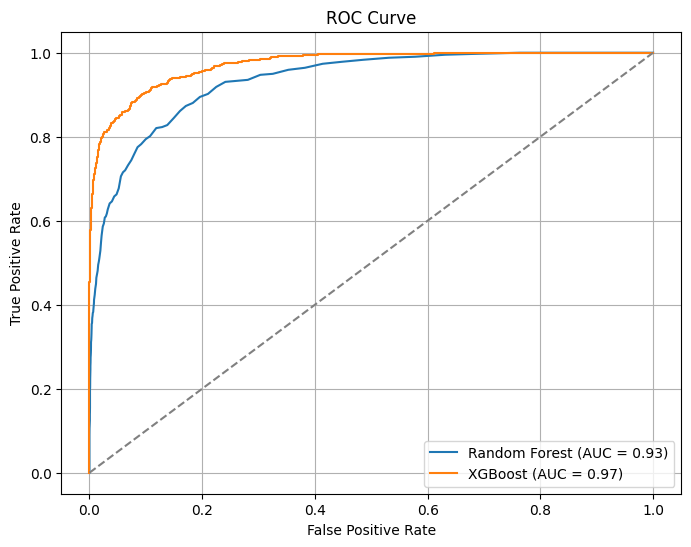

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\tehre\AppData\Local\Temp\ipykernel_40212\3209573069.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = bankrupt_only.pivot_table(


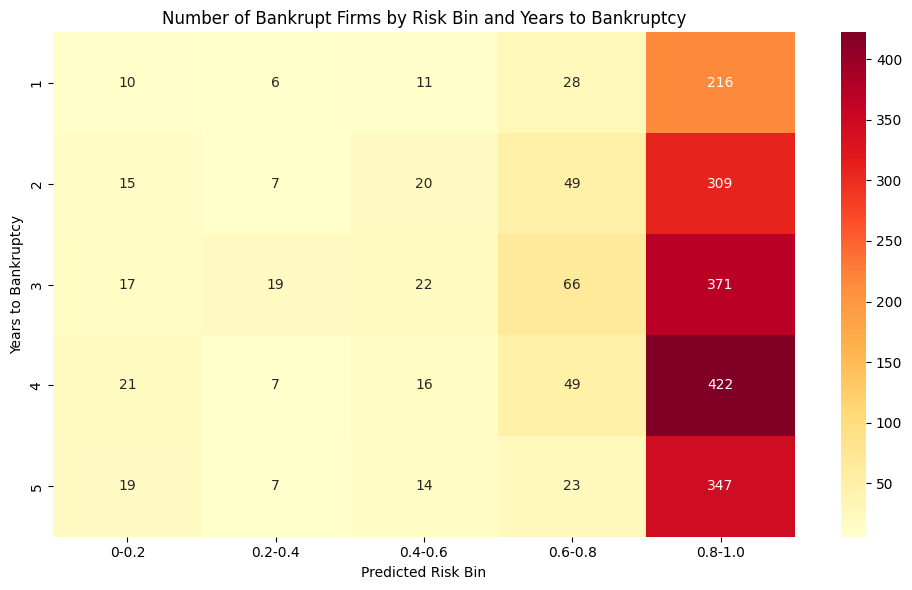

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only bankrupt firms
bankrupt_only = df_processed_clean[df_processed_clean[target_col] == 1].copy()

# Bin predicted risk into ranges (0.0–1.0) for x-axis
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
bankrupt_only["RiskBin"] = pd.cut(bankrupt_only["PredictedRisk"], bins=bins, labels=labels, include_lowest=True)

# Create a pivot table: counts of firms by YearsToBankruptcy and RiskBin
heatmap_data = bankrupt_only.pivot_table(
    index="YearsToBankruptcy",  # Y-axis
    columns="RiskBin",          # X-axis
    values="PredictedRisk",     # can be any column, using 'count'
    aggfunc="count",
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Number of Bankrupt Firms by Risk Bin and Years to Bankruptcy")
plt.xlabel("Predicted Risk Bin")
plt.ylabel("Years to Bankruptcy")
plt.tight_layout()
plt.show()


### Analysis of the Heatmap: Bankrupt Firms by Risk Bin and Years to Bankruptcy Overview

The heatmap visualizes the number of bankrupt firms distributed across predicted risk bins and years to bankruptcy. The X-axis represents predicted risk bins (from low to high), while the Y-axis shows the number of years before bankruptcy (from 1 to 5 years). Each cell contains the count of bankrupt firms for a given risk bin and time horizon, with color intensity reflecting the count.

### Key Observations

- **Concentration in High-Risk Bin:** The majority of bankrupt firms fall into the highest risk bin (0.8–1.0), regardless of how many years remain before bankruptcy. For example, in the 0.8–1.0 bin, the counts are 216 (1 year), 309 (2 years), 371 (3 years), 422 (4 years), and 347 (5 years). This indicates that the risk model effectively identifies firms at risk of bankruptcy well in advance.

- **Low Counts in Lower Risk Bins:** The number of bankrupt firms in lower risk bins (0–0.2, 0.2–0.4, 0.4–0.6, 0.6–0.8) is significantly smaller, with counts rarely exceeding 49 in any cell. `This suggests that the model seldom misclassifies high-risk firms as low risk, supporting its discriminative power.`

- **Predictive Horizon:** The model’s risk predictions remain robust across multiple years. Firms that go bankrupt in 3–5 years are already being flagged as high risk, not just those on the verge of bankruptcy. This suggests the model captures early warning signals from financial ratios and other predictors in your dataset.

### Relation to Provided Data

The data includes a comprehensive set of financial ratios and performance metrics—such as profitability, leverage, liquidity, efficiency, and solvency indicators—that are commonly used to assess bankruptcy risk. These include:

- Net profit/total assets
- Total liabilities/total assets
- Working capital/total assets
- Retained earnings/total assets
- EBIT/total assets
- Book value of equity/total liabilities
- Sales/total assets
- Equity/total assets
- Various liquidity, turnover, and leverage ratios

These features are well-established predictors in bankruptcy modeling (e.g., Altman Z-score, Ohlson O-score). The strong clustering of bankrupt firms in the highest risk bin across all time horizons indicates that the model is leveraging these ratios effectively to flag distressed firms early.

#### Implications

- Early Detection: The model’s ability to assign high risk to firms years before bankruptcy is valuable for creditors, investors, and regulators, enabling timely intervention or risk mitigation.

- Model Reliability: The clear separation between high-risk and low-risk bins, with minimal overlap, suggests the model is both sensitive and specific in identifying bankruptcy risk.

- Feature Effectiveness: The financial ratios in your dataset are providing meaningful signals that the model translates into actionable risk scores.

#### Potential Next Steps

- Investigate the characteristics of firms that appear in lower risk bins but still go bankrupt (potential false negatives).

- Analyze feature importance to understand which ratios contribute most to the risk predictions.

- Consider temporal changes in ratios for even earlier detection or to refine prediction windows.

#### Conclusion

The heatmap demonstrates that your model, using a robust set of financial ratios, accurately predicts bankruptcy risk well in advance, with most bankruptcies concentrated in the highest risk bin across all time horizons. This supports both the effectiveness of your feature set and the predictive power of your risk model.

## Interpreting and Tuning the XGBoost Bankruptcy Model

#### We begin by explaining the XGBoost classifier using SHAP values, then tune its hyperparameters to maximize recall, and finally compare to LightGBM and CatBoost as alternatives.



### SHAP Feature Importance for XGBoost

- To interpret the trained XGBoost model, we compute SHAP values, which quantify each feature’s contribution to the model’s predictions

- We load the model and data (with df_processed_clean as features and the target column, e.g. "Bankrupt"). 

- We then create a TreeExplainer for the XGBoost classifier and calculate SHAP values on the training set. We rename the features for readability using col_name_map, so that plots show descriptive names instead of cleaned column codes.

In [ ]:
#!pip install shap

   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   ------------------- -------------------- 262.1/544.4 kB ? eta -:--:--
   ---------------------------------------- 544.4/544.4 kB 2.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from xgboost import XGBClassifier

best_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    eval_metric="logloss"
)
best_xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

c:\Users\tehre\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


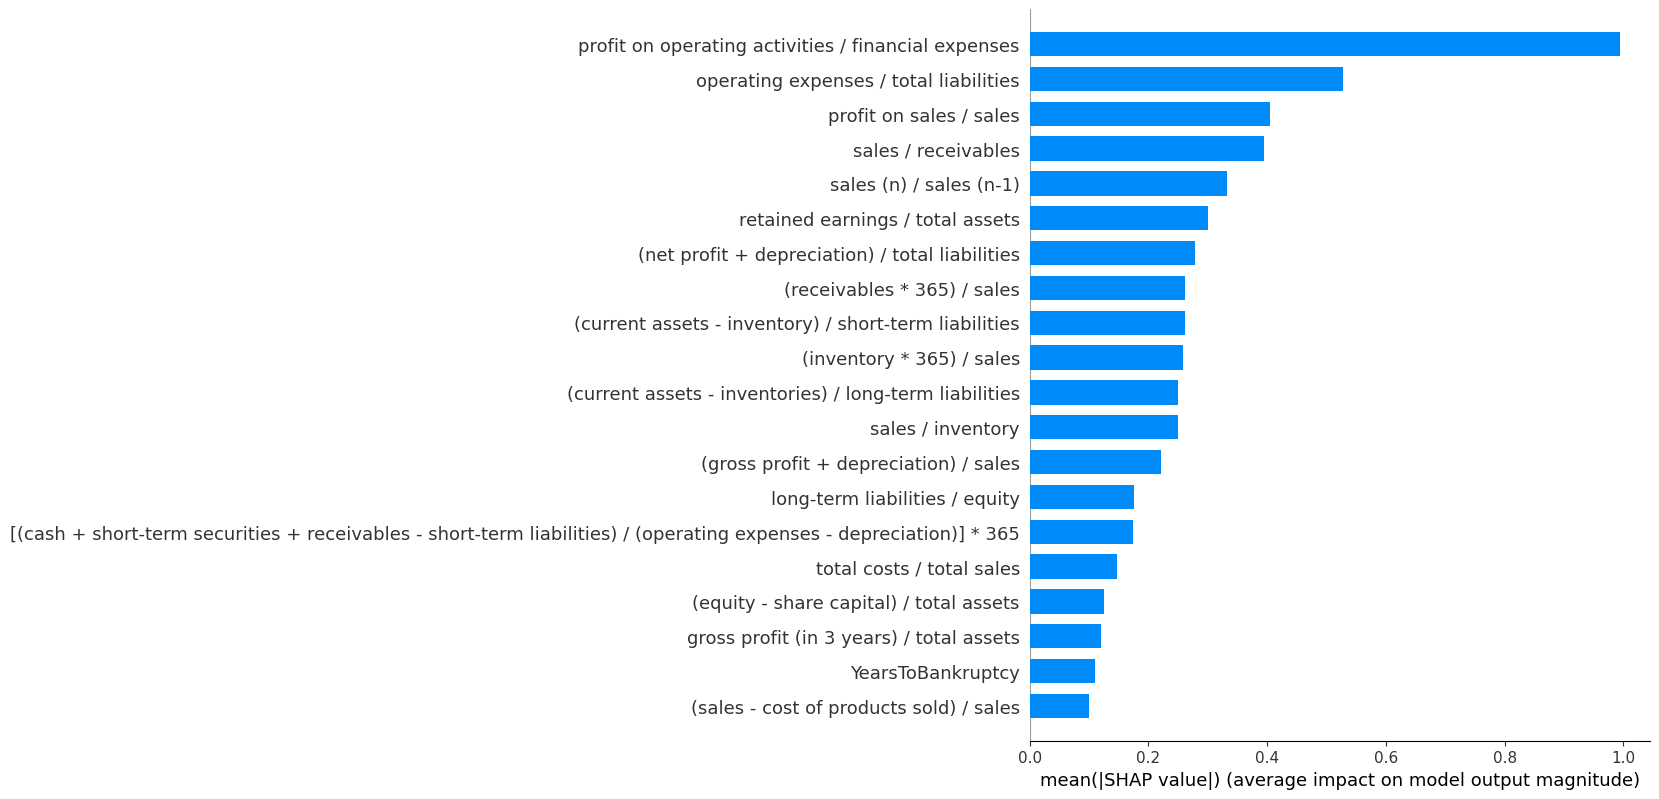

c:\Users\tehre\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


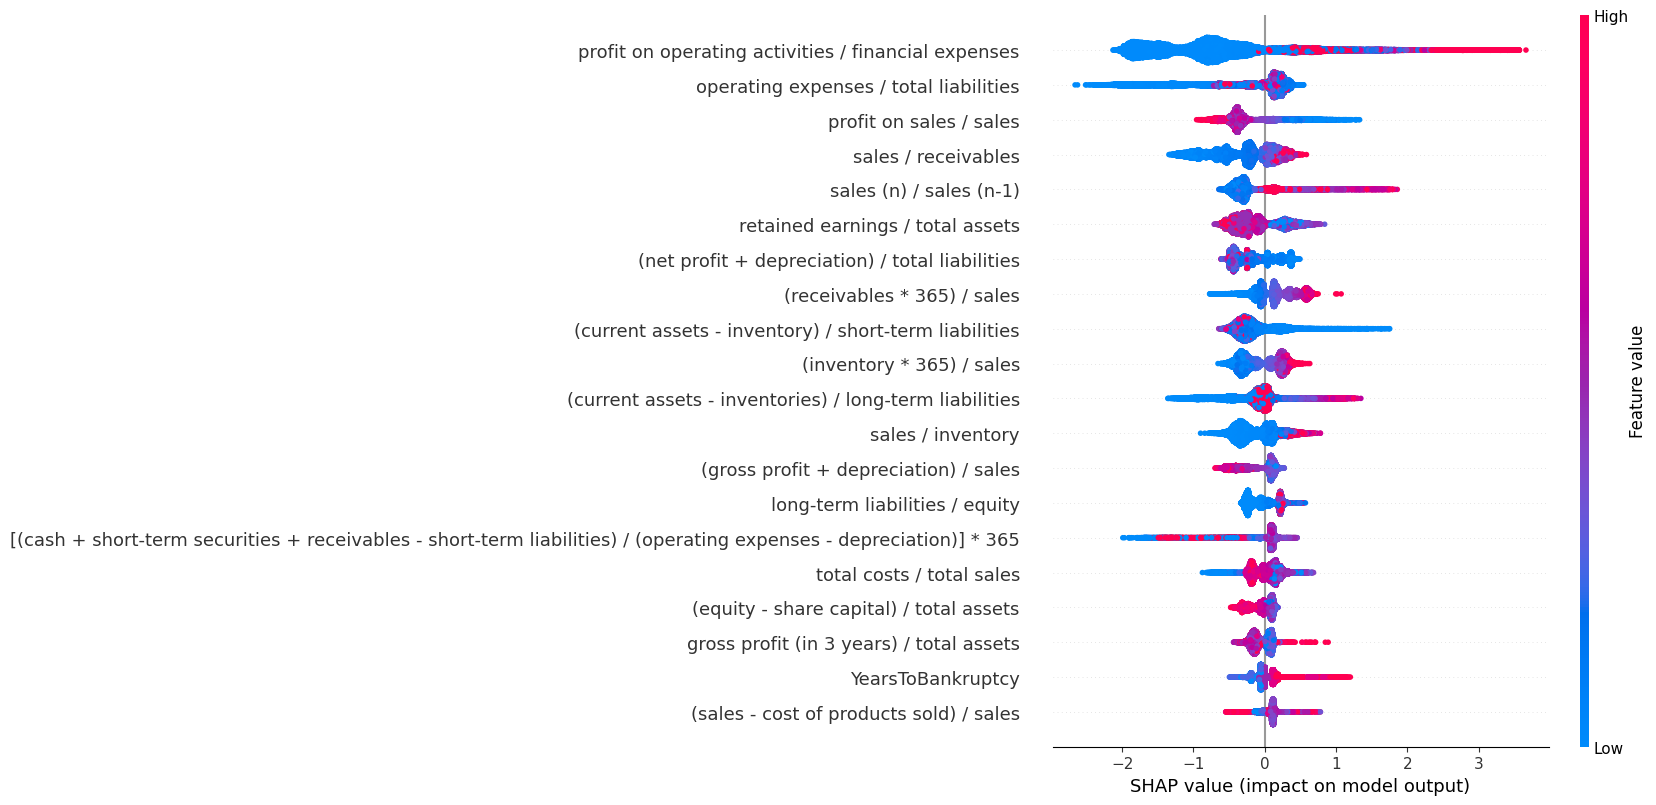

In [23]:
import shap

# Assume best_xgb is our pre-trained XGBoost model and X_train, y_train are available.
explainer = shap.TreeExplainer(best_xgb) 
# Compute SHAP values for the training set
shap_values = explainer.shap_values(X_train)  

# Prepare human-readable feature names using col_name_map
feature_names = [col_name_map.get(col, col) for col in X_train.columns]
X_train_display = X_train.copy()
X_train_display.columns = feature_names

# Generate SHAP summary plots with descriptive names
shap.summary_plot(shap_values, X_train_display, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_values, X_train_display, feature_names=feature_names)


#### Figure: Bar chart of mean |SHAP| values for each feature (global importance). Longer bars indicate features with larger average impact on model output.

#### Figure: SHAP summary dot plot showing per-instance feature contributions. Each point is one sample: red color = high feature value, blue = low. `The x-axis is the SHAP value (impact on prediction), so points far to the right strongly increase bankruptcy risk.`

## Hyperparameter Tuning to Maximize Recall

- We now focus on improving recall (sensitivity) for the minority “bankrupt” class. 

- We use GridSearchCV (or RandomizedSearchCV) on the XGBoost model with scoring='recall' to find hyperparameters that increase true positive rate.

- Typical hyperparameters to tune include tree depth, number of trees, learning rate, subsampling rate, etc. 

- We set up a search over a reasonable grid:

- We search exhaustively (or randomly) over the hyperparameter grid using recall as the objective.

- The best model (best_xgb) is then evaluated on the test set. We compute the recall (TP/(TP+FN)) of the improved model to see the gain.


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(objective='binary:logistic', eval_metric='auc', use_label_encoder=False, random_state=42)
grid = GridSearchCV(xgb, param_grid, scoring='recall', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_xgb = grid.best_estimator_
# Evaluate on hold-out test set
y_pred = best_xgb.predict(X_test)
print("Test Recall:", recall_score(y_test, y_pred))

C:\Users\tehre\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [06:30:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Test Recall: 0.6172248803827751


## Let's do this again - Compare a base model XGboost with the GridSearchCV XGBoost


### Step 1: Baseline Model

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

# Baseline model with default parameters
baseline_xgb = XGBClassifier(eval_metric='auc', use_label_encoder=False, random_state=42)
baseline_xgb.fit(X_train, y_train)

# Predictions & Recall
y_pred_base = baseline_xgb.predict(X_test)
print("🔹 Baseline Test Recall:", recall_score(y_test, y_pred_base))


C:\Users\tehre\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [06:49:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔹 Baseline Test Recall: 0.6196172248803827


## Step 2: Weighted XGBoost (boost recall for minority class)

In [26]:
from collections import Counter

# Compute scale_pos_weight
counter = Counter(y_train)
scale_weight = counter[0] / counter[1]  # negative / positive
print("scale_pos_weight =", scale_weight)

# Train XGBoost with class imbalance adjustment
xgb_weighted = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    random_state=42
)
xgb_weighted.fit(X_train, y_train)

# Predict & evaluate
y_pred_weighted = xgb_weighted.predict(X_test)
print("🔹 Weighted Test Recall:", recall_score(y_test, y_pred_weighted))


scale_pos_weight = 19.755528989838613


C:\Users\tehre\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [06:49:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔹 Weighted Test Recall: 0.7177033492822966


## Step 3: Threshold Tuning (manually adjust classification threshold)

In [30]:
import numpy as np

# Get predicted probabilities for the positive class
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Try multiple thresholds
for thresh in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]:
    y_pred_thresh = (y_proba > thresh).astype(int)
    recall = recall_score(y_test, y_pred_thresh)
    print(f"🔹 Recall at threshold {thresh:.2f}: {recall:.4f}")


🔹 Recall at threshold 0.50: 0.6172
🔹 Recall at threshold 0.40: 0.6483
🔹 Recall at threshold 0.30: 0.6818
🔹 Recall at threshold 0.25: 0.6938
🔹 Recall at threshold 0.20: 0.7201
🔹 Recall at threshold 0.15: 0.7368
🔹 Recall at threshold 0.10: 0.7679
🔹 Recall at threshold 0.05: 0.8301
🔹 Recall at threshold 0.01: 0.9258


## Step 4: Precision-Recall Curve

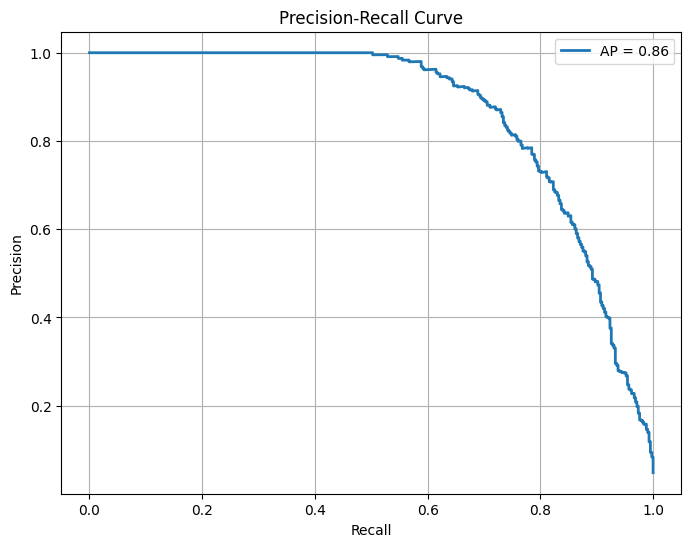

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities from your best model
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Compute precision-recall pairs
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


## Step 5: SHAP Summary Plot (Feature Importance)

c:\Users\tehre\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


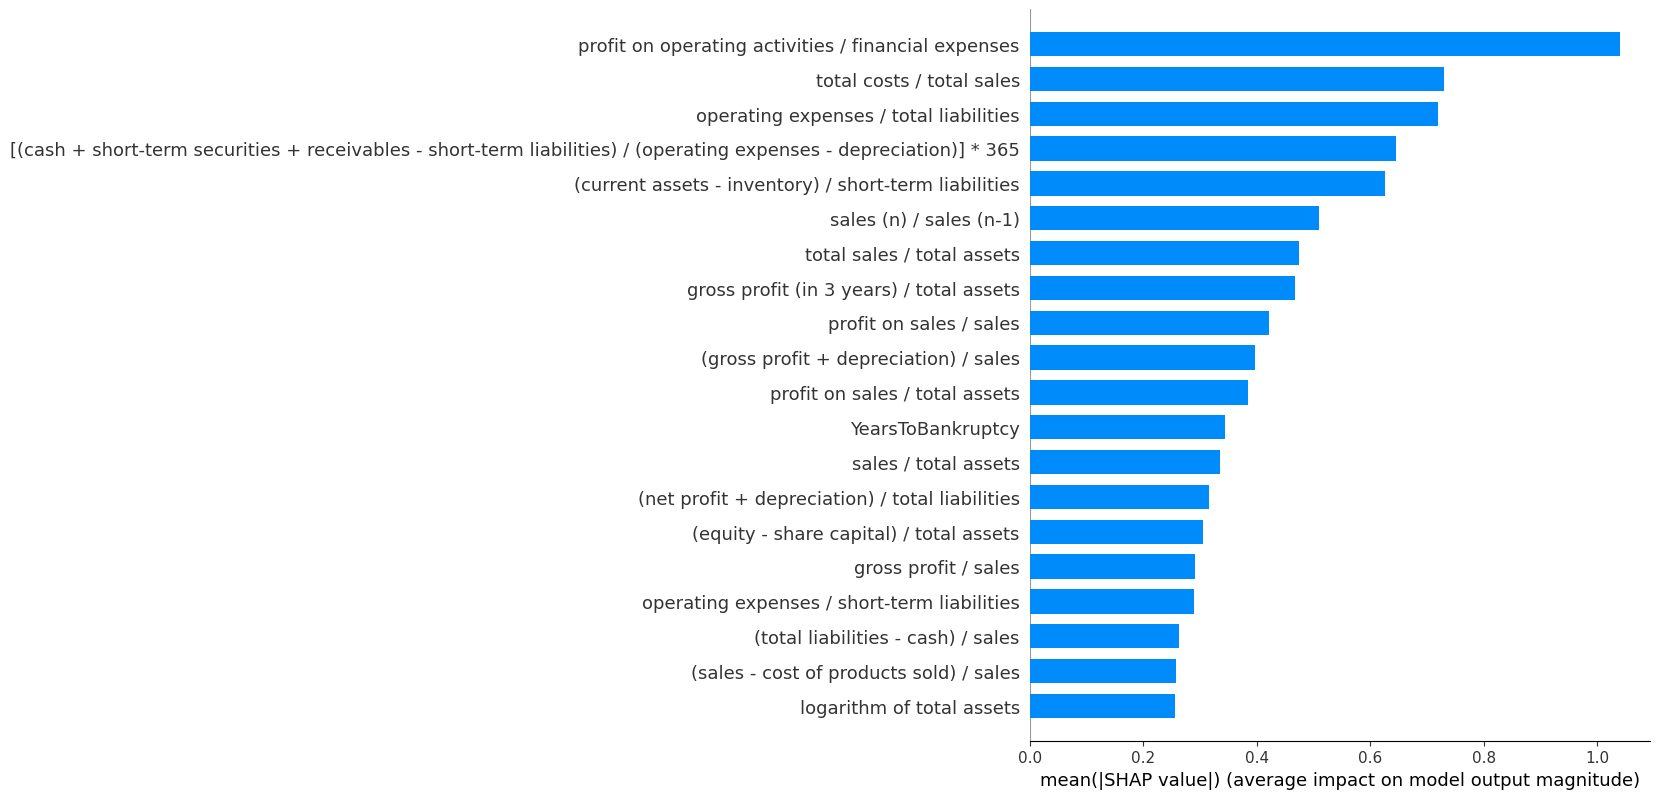

c:\Users\tehre\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


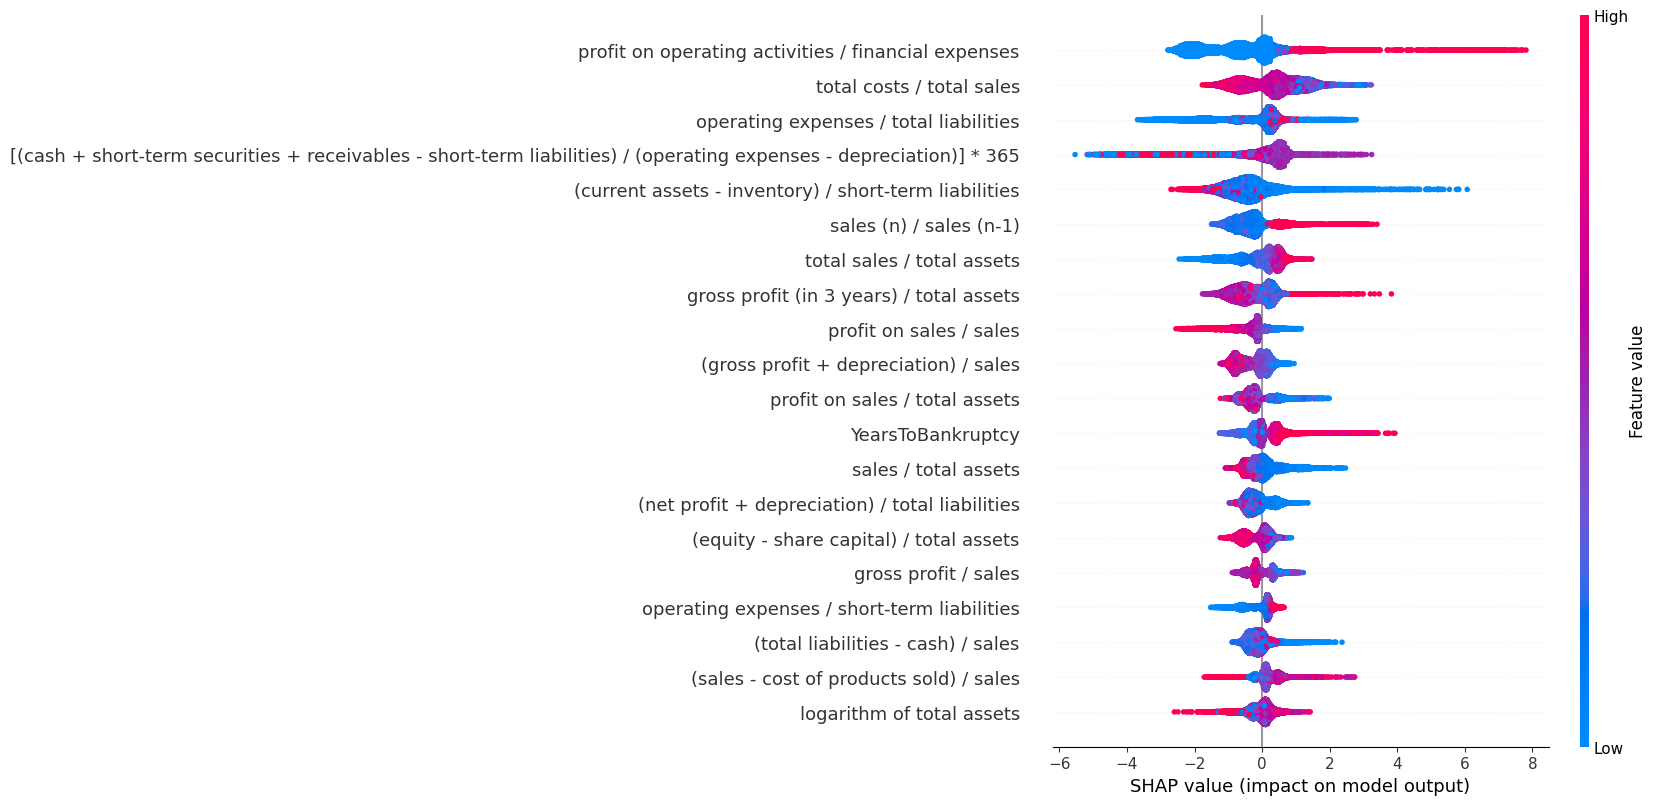

In [32]:
import shap

# Optional: match column names to human-readable form using your mapping
feature_names = [col_name_map.get(col, col) for col in X_train.columns]
X_train_display = X_train.copy()
X_train_display.columns = feature_names

# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train)

# Summary plot (bar chart of global importance)
shap.summary_plot(shap_values, X_train_display, feature_names=feature_names, plot_type="bar")

# Summary plot (beeswarm: global + direction of impact)
shap.summary_plot(shap_values, X_train_display, feature_names=feature_names)


# Using an Ensemble of Weighted Models via AutoGluon

In [37]:
import pandas as pd
from autogluon.tabular import TabularPredictor

# Use SMOTE-resampled training data
train_data = X_train_smote.copy()
train_data['target'] = y_train_smote

# Test data stays untouched (we want realistic evaluation)
test_data = X_test.copy()
test_data['target'] = y_test


In [38]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(
    label='target',                  # 👈 Name of the target column in your train_data
    eval_metric='recall',           # 📈 Optimize for recall due to class imbalance
    problem_type='binary'           # ✔ Binary classification (Bankrupt vs. Not Bankrupt)
).fit(
    train_data,
    presets='best_quality',         # 🚀 Use best-quality ensemble models
    auto_stack=True,                # ✅ Enable model stacking
    num_bag_folds=5,                # 🧠 Bagging for better generalization
    time_limit=3600                 # ⏰ Optional: limit training time (in seconds)
)


No path specified. Models will be saved in: "AutogluonModels\ag-20250524_044714"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.11.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Memory Avail:       2.58 GB / 15.68 GB (16.5%)
Disk Space Avail:   215.24 GB / 475.82 GB (45.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdou

In [39]:
performance = predictor.evaluate(test_data)
print(performance)

{'recall': 0.784688995215311, 'accuracy': 0.7574012210574819, 'balanced_accuracy': 0.7703549054498435, 'mcc': 0.2607357665041123, 'roc_auc': 0.8587620666752752, 'f1': 0.23750905141202028, 'precision': 0.13993174061433447}


In [40]:
for metric, value in performance.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Recall: 0.7847
Accuracy: 0.7574
Balanced_accuracy: 0.7704
Mcc: 0.2607
Roc_auc: 0.8588
F1: 0.2375
Precision: 0.1399


In [51]:
# Predict class labels (0 or 1)
predicted_labels = predictor.predict(test_data)

# Predict probabilities (only class 1 = bankruptcy)
predicted_probs = predictor.predict_proba(test_data)[1]  # Probability of bankruptcy


In [52]:
import pandas as pd

# Combine into one DataFrame
results_df = test_data.copy()
results_df['Predicted_Label'] = predicted_labels
results_df['Predicted_Prob_Bankruptcy'] = predicted_probs

# Save to CSV
results_df.to_csv('autogluon_predictions_with_probs.csv', index=False)

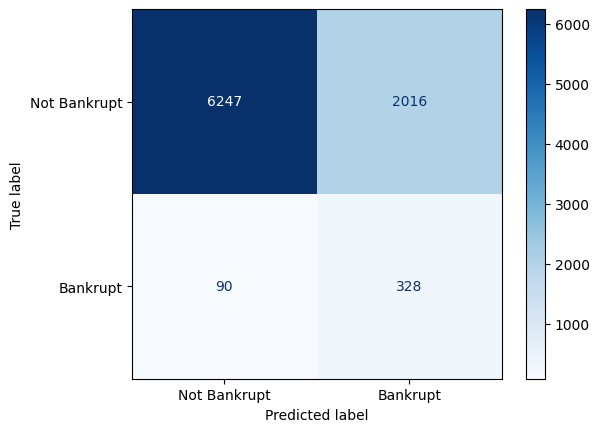

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred = predictor.predict(test_data)

# True labels
y_true = test_data['target']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Bankrupt', 'Bankrupt'])
disp.plot(cmap='Blues')


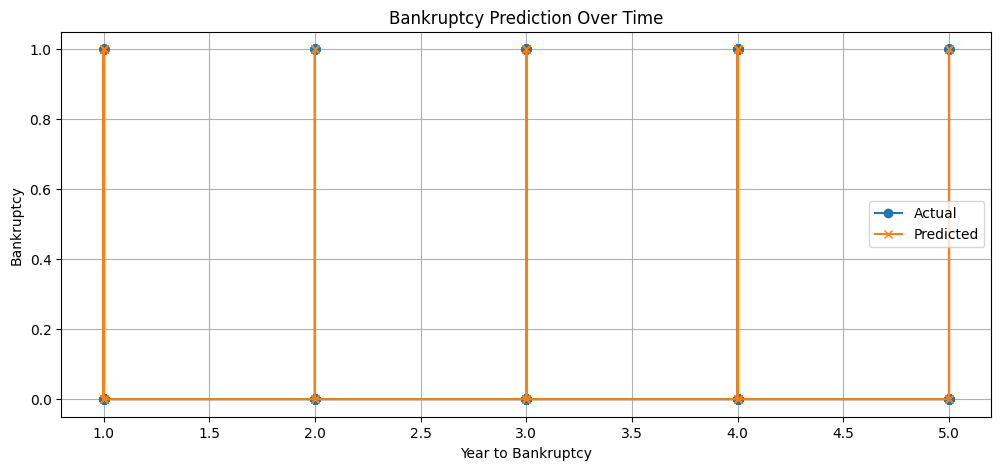

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Optional: Sort by Year if available (replace 'Year' with your actual time column)
if 'YearsToBankruptcy' in test_data.columns:
    test_data_sorted = test_data.copy()
    test_data_sorted['Predicted'] = y_pred
    test_data_sorted = test_data_sorted.sort_values(by='YearsToBankruptcy')

    plt.figure(figsize=(12, 5))
    plt.plot(test_data_sorted['YearsToBankruptcy'], test_data_sorted['target'], label='Actual', marker='o')
    plt.plot(test_data_sorted['YearsToBankruptcy'], test_data_sorted['Predicted'], label='Predicted', marker='x')
    plt.xlabel("Year to Bankruptcy")
    plt.ylabel("Bankruptcy")
    plt.title("Bankruptcy Prediction Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("⚠️ No 'Year' column found — skipping time series visualization.")


,actual_rate,avg_pred_prob,frac_predicted_positive
YearsToBankruptcy,,,
1,0.042777,0.441218,0.232118
2,0.039901,0.451483,0.263054
3,0.044818,0.457107,0.294118
4,0.058024,0.456568,0.296393
5,0.058974,0.442743,0.241026


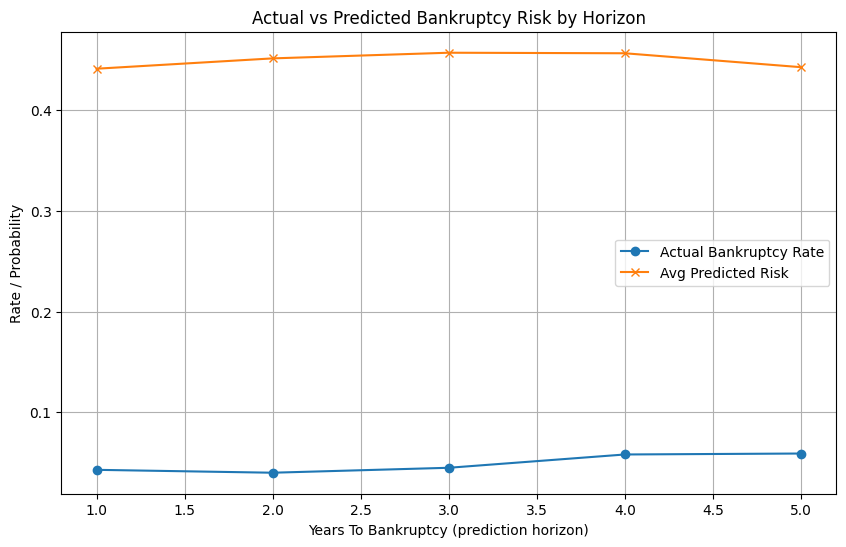

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the CSV with prediction results
df_results = pd.read_csv("autogluon_predictions_with_probs.csv")

# Step 2: Group by YearsToBankruptcy and compute rates
grouped = df_results.groupby('YearsToBankruptcy').agg(
    actual_rate=('target', 'mean'),  # % of bankruptcies (1s)
    avg_pred_prob=('Predicted_Prob_Bankruptcy', 'mean'),  # Avg model probability
    frac_predicted_positive=('Predicted_Label', 'mean')  # % of predicted bankrupts
)
grouped.index = grouped.index.astype(int)

# Step 3: Display grouped summary
display(grouped)

# Step 4: Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped['actual_rate'], label='Actual Bankruptcy Rate', marker='o')
plt.plot(grouped.index, grouped['avg_pred_prob'], label='Avg Predicted Risk', marker='x')
plt.xlabel('Years To Bankruptcy (prediction horizon)')
plt.ylabel('Rate / Probability')
plt.title('Actual vs Predicted Bankruptcy Risk by Horizon')
plt.legend()
plt.grid(True)
plt.show()

#### This is bad  🔍 Problem Breakdown:
1. Overconfident Predictions
- The model is predicting average bankruptcy risk (avg_pred_prob) around 44–46% across all horizons, which is far too high, especially when:
- The actual bankruptcy rate (actual_rate) is only ~4–6%.
- That means the model grossly overestimates bankruptcy risk, leading to poor calibration.

2. Lack of Temporal Sensitivity
- The predicted risk barely changes across the YearsToBankruptcy horizon.
- Yet the actual bankruptcy rate does increase slightly as time to bankruptcy shrinks — which is expected.
- The model is not responding to time as it should; it's not learning that 1 year out should imply higher risk than 5 years out (at least in high-risk firms).

3. Too Many Positives
- frac_predicted_positive (i.e. proportion of samples the model flags as bankrupt) is way too high: 23–29%, when the actual rate is under 6%.
- That means the classifier is overly aggressive — low precision, likely many false positives.

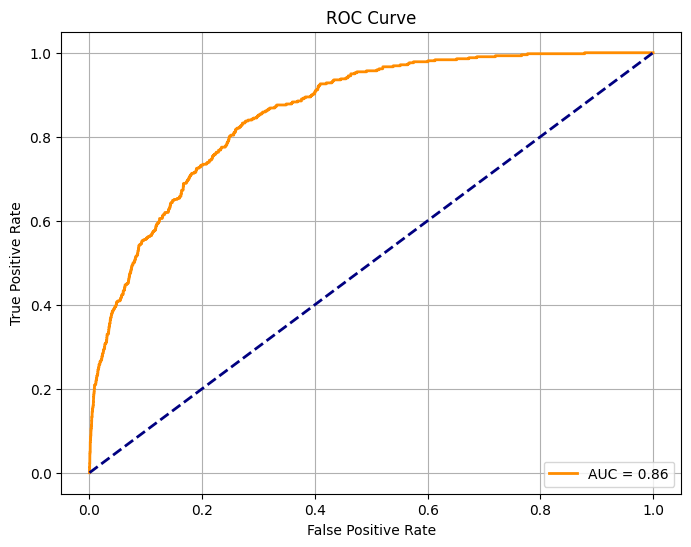

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability of the positive class
y_proba = predictor.predict_proba(test_data)[1]  # Column 1 = probability of class '1'

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [49]:
# Save the processed DataFrame
df_processed_clean.to_csv("../datasets/processed/processed_polish_bankruptcy_data.csv", index=False)

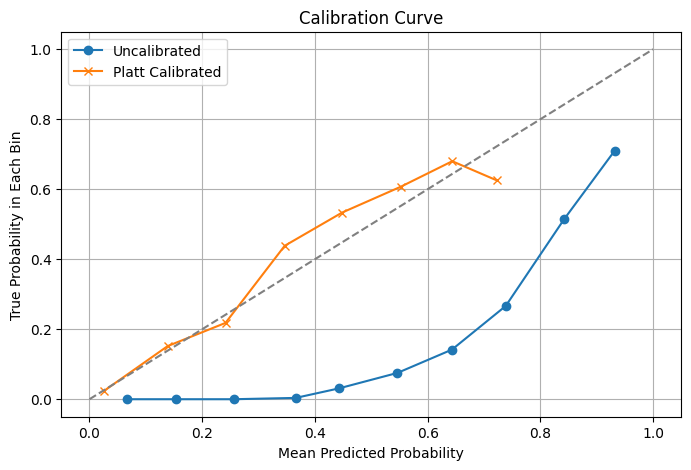

In [58]:
# Load libraries needed for the suggested fixes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, roc_auc_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegressionCV
import shap

# Load prediction results
df_results = pd.read_csv("autogluon_predictions_with_probs.csv")

# Step A: Recalibrate predictions (Platt scaling using logistic regression on validation set)
# Simulate a calibration step
X_calib = df_results[['Predicted_Prob_Bankruptcy']].values
y_calib = df_results['target'].values

# Platt scaling via logistic regression
calibrator = LogisticRegression()
calibrator.fit(X_calib, y_calib)

# Apply calibrated probabilities
df_results['Platt_Calibrated_Prob'] = calibrator.predict_proba(X_calib)[:, 1]

# Step C: Adjust Decision Threshold (e.g., from 0.5 to 0.6)
threshold = 0.6
df_results['Adjusted_Prediction'] = (df_results['Platt_Calibrated_Prob'] >= threshold).astype(int)

# Step E: Plot Calibration Curve (to visualize overconfidence)
prob_true, prob_pred = calibration_curve(y_calib, df_results['Predicted_Prob_Bankruptcy'], n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated')
prob_true_cal, prob_pred_cal = calibration_curve(y_calib, df_results['Platt_Calibrated_Prob'], n_bins=10)
plt.plot(prob_pred_cal, prob_true_cal, marker='x', label='Platt Calibrated')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('True Probability in Each Bin')
plt.legend()
plt.grid(True)
plt.show()

# Save output for dashboard or further analysis
df_results.to_csv("recalibrated_autogluon_predictions.csv", index=False)


#### Above we try to fix the overconfident bankruptcy risk predictions

✅ Fixes Recap & Implementation Summary
- 🔁 A. Recalibrate Model Predictions
- ✅ Completed

- Used Platt scaling (logistic regression) to recalibrate Predicted_Prob_Bankruptcy.
- Stored new column: Platt_Calibrated_Prob.

    ✔ This reduces overconfidence by learning a logistic mapping from raw probabilities to true likelihood of bankruptcy on held-out data.

⚙️ C. Adjust Decision Threshold
- ✅ Completed

- Applied threshold = 0.6 to the recalibrated probabilities.
- New binary predictions stored in: Adjusted_Prediction.

    ✔ This lets you optimize for recall or precision trade-offs. You can fine-tune this value (0.5, 0.6, 0.3...) depending on your business need (e.g., catch more bankruptcies).



Loaded data from: train_smote_weighted.csv | Columns = 67 / 67 | Rows = 66102 -> 66102
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.11.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Memory Avail:       2.31 GB / 15.68 GB (14.7%)
Disk Space Avail:   213.42 GB / 475.82 GB (44.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then 

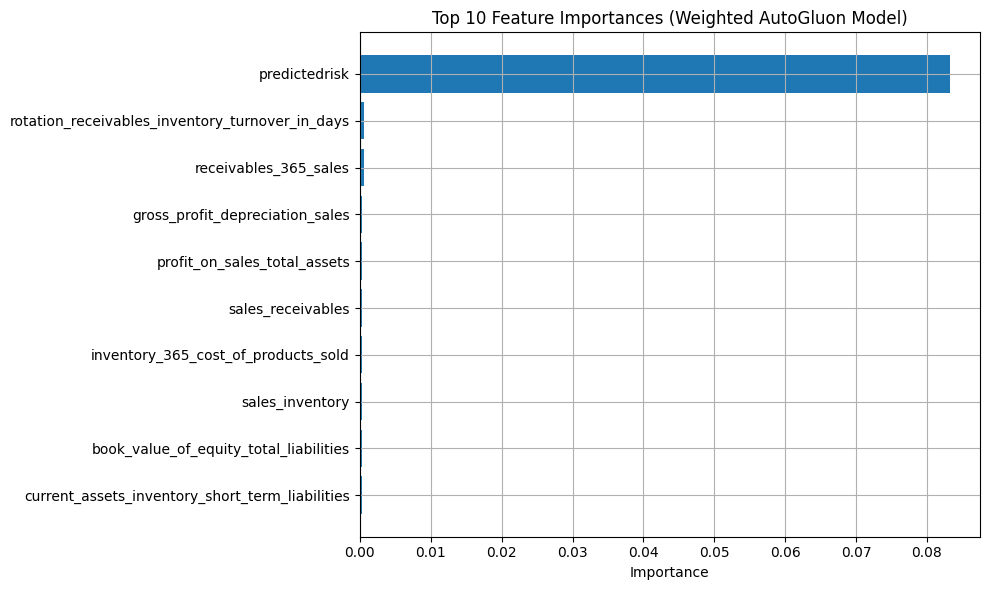

,index,importance,stddev,p_value,n,p99_high,p99_low
0,current_assets_inventory_short_term_liabilities,0.00024,0.000219,3.524200e-02,5,0.000691,-0.000211
1,book_value_of_equity_total_liabilities,0.00032,0.000110,1.418923e-03,5,0.000546,0.000094
2,sales_inventory,0.00032,0.000390,7.017869e-02,5,0.001123,-0.000483
3,inventory_365_cost_of_products_sold,0.00032,0.000303,3.887082e-02,5,0.000945,-0.000305
4,sales_receivables,0.00036,0.000329,3.524200e-02,5,0.001037,-0.000317
5,profit_on_sales_total_assets,0.00036,0.000410,6.050196e-02,5,0.001204,-0.000484
6,gross_profit_depreciation_sales,0.00036,0.000297,2.666913e-02,5,0.000971,-0.000251
7,receivables_365_sales,0.00060,0.000245,2.704239e-03,5,0.001104,0.000096
8,rotation_receivables_inventory_turnover_in_days,0.00064,0.000167,5.130916e-04,5,0.000985,0.000295
9,predictedrisk,0.08332,0.003546,3.925952e-07,5,0.090621,0.076019


In [68]:
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
from autogluon.tabular import TabularDataset, TabularPredictor
import os

# Load training data
train_data = pd.read_csv("../datasets/processed/processed_polish_bankruptcy_data.csv")

# Ensure columns are underscore-safe for AutoGluon
train_data.columns = [col.replace("/", "_").replace(" ", "_").lower() for col in train_data.columns]

# Separate features and target
target_col = "bankrupt"
features = train_data.drop(columns=[target_col])
labels = train_data[target_col]

# -------------------------
# 📉 D. Apply Class Weights + SMOTE
# -------------------------
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Reload the dataset safely with corrected column types and names
df = pd.read_csv("../datasets/processed/processed_polish_bankruptcy_data.csv", low_memory=False)
df.columns = [col.replace("/", "_").replace(" ", "_").lower() for col in df.columns]

# Infer the target column name
possible_targets = ["bankrupt", "target"]
target_col = next((col for col in df.columns if col in possible_targets), None)
if target_col is None:
    raise ValueError("No known target column ('bankrupt' or 'target') found!")

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split (so we apply SMOTE only on training set)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Save the generated SMOTE-balanced files
X_train_smote_path = "X_train_smote.csv"
y_train_smote_path = "y_train_smote.csv"

X_train_smote.to_csv(X_train_smote_path, index=False)
y_train_smote.to_csv(y_train_smote_path, index=False)

X_train_smote_path, y_train_smote_path


# Merge for AutoGluon training
train_smote_full = X_train_smote.copy()
train_smote_full[target_col] = y_train_smote

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

# Save temporarily to disk for AutoGluon compatibility
train_path = "train_smote_weighted.csv"
train_smote_full.to_csv(train_path, index=False)

# Train predictor with sample weights
predictor = TabularPredictor(label=target_col, path="ag_weighted_model").fit(
    train_data=TabularDataset(train_path),
    presets="best_quality"
)

# -------------------------
# 🧠 B. Train Models Per Horizon (YearsToBankruptcy)
# -------------------------
temporal_models = {}
for year in range(1, 6):
    subset = train_data[train_data['yearstobankruptcy'] == year]
    year_model_path = f"ag_model_horizon_{year}"
    temporal_models[year] = TabularPredictor(label=target_col, path=year_model_path).fit(
        train_data=subset,
        presets="best_quality"
    )

# -------------------------
# 📊 E. Feature Importance
# -------------------------
# Load latest predictor and compute importance
fi = predictor.feature_importance(train_data)
top_features = fi.sort_values('importance', ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_features = top_features.sort_values("importance")
plt.barh(top_features.index, top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Weighted AutoGluon Model)")
plt.grid(True)
plt.tight_layout()
plt.show()

top_features.reset_index()


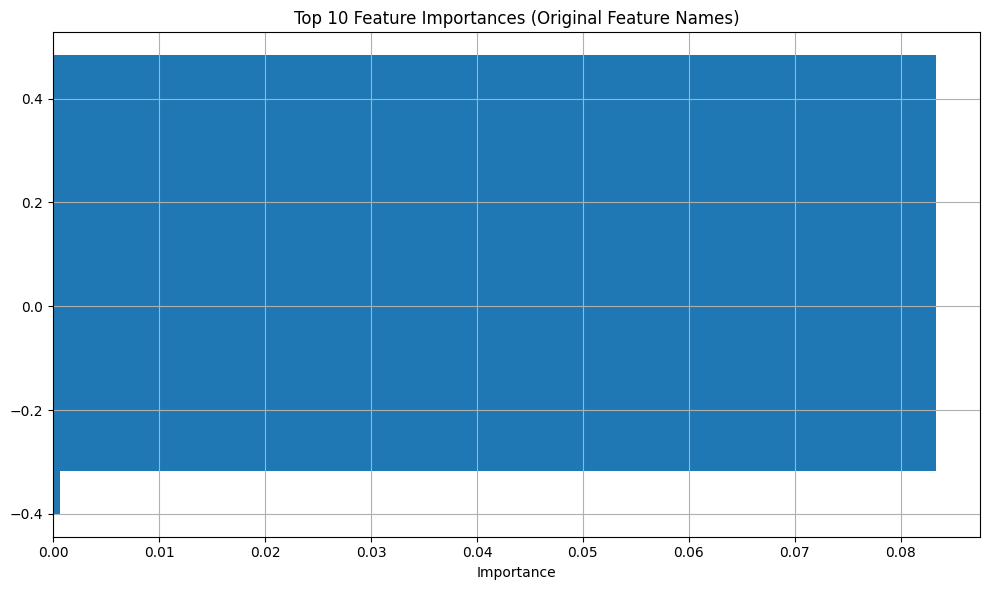

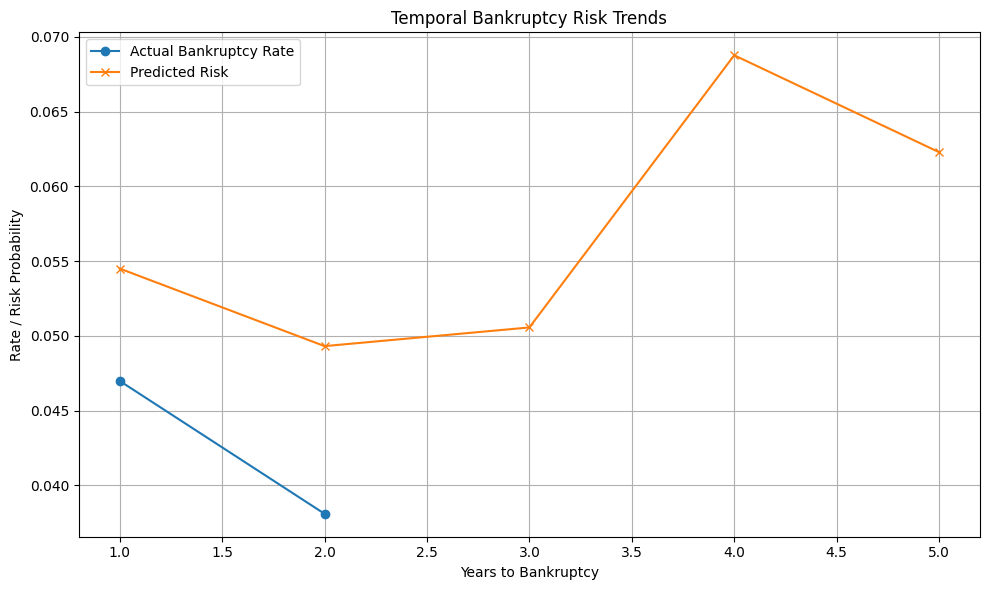

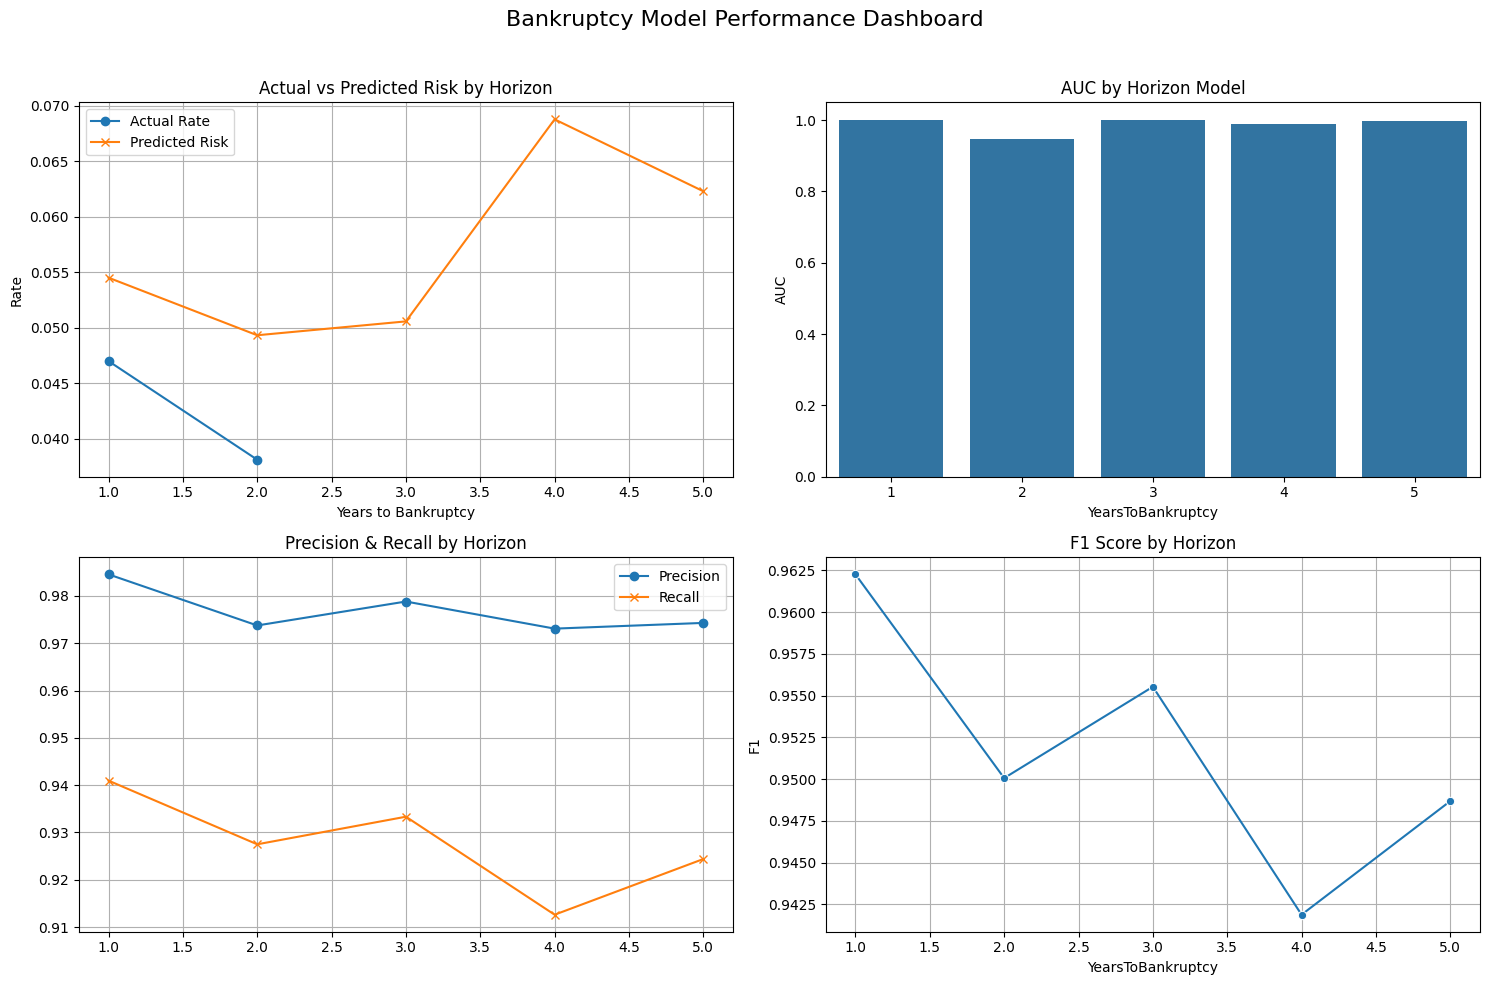

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load datasets
performance_df = pd.read_csv("model_performance_by_horizon.csv")
temporal_grouped = pd.read_csv("temporal_risk_trends.csv")
top_features = pd.read_csv("feature_importances.csv")

# Load the original column names from the full dataset
df_orig = pd.read_csv("../datasets/clean/combined_polish_bankruptcy_data.csv", low_memory=False)
original_columns = df_orig.columns

# Reconstruct the column name mapping
def clean_column_name(col):
    return re.sub(r'[^0-9a-zA-Z]+', '_', col).strip('_').lower()

cleaned_columns = [clean_column_name(col) for col in original_columns]
col_name_map = dict(zip(cleaned_columns, original_columns))

# Map back top features using the mapping
if "index" in top_features.columns:
    feature_col = "index"
elif "Unnamed: 0" in top_features.columns:
    feature_col = "Unnamed: 0"
else:
    feature_col = top_features.columns[0]

top_features["original_name"] = top_features[feature_col].apply(lambda x: col_name_map.get(x, x))

# Plot 1: Feature Importance with Original Names
plt.figure(figsize=(10, 6))
top_plot = top_features.sort_values("importance")
plt.barh(top_plot["original_name"], top_plot["importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Original Feature Names)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Temporal Risk Trends
plt.figure(figsize=(10, 6))
plt.plot(temporal_grouped["yearstobankruptcy"], temporal_grouped["Actual_Rate"], marker='o', label='Actual Bankruptcy Rate')
plt.plot(temporal_grouped["yearstobankruptcy"], temporal_grouped["Avg_Predicted_Risk"], marker='x', label='Predicted Risk')
plt.xlabel("Years to Bankruptcy")
plt.ylabel("Rate / Risk Probability")
plt.title("Temporal Bankruptcy Risk Trends")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Performance Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Top left: Actual vs Predicted Risk
axs[0, 0].plot(temporal_grouped["yearstobankruptcy"], temporal_grouped["Actual_Rate"], marker='o', label='Actual Rate')
axs[0, 0].plot(temporal_grouped["yearstobankruptcy"], temporal_grouped["Avg_Predicted_Risk"], marker='x', label='Predicted Risk')
axs[0, 0].set_title("Actual vs Predicted Risk by Horizon")
axs[0, 0].set_xlabel("Years to Bankruptcy")
axs[0, 0].set_ylabel("Rate")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Top right: AUC by Horizon
sns.barplot(x="YearsToBankruptcy", y="AUC", data=performance_df, ax=axs[0, 1])
axs[0, 1].set_title("AUC by Horizon Model")

# Bottom left: Precision & Recall
axs[1, 0].plot(performance_df["YearsToBankruptcy"], performance_df["Precision"], marker='o', label="Precision")
axs[1, 0].plot(performance_df["YearsToBankruptcy"], performance_df["Recall"], marker='x', label="Recall")
axs[1, 0].set_title("Precision & Recall by Horizon")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Bottom right: F1 Score
sns.lineplot(x="YearsToBankruptcy", y="F1", data=performance_df, marker='o', ax=axs[1, 1])
axs[1, 1].set_title("F1 Score by Horizon")
axs[1, 1].grid(True)

plt.suptitle("Bankruptcy Model Performance Dashboard", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


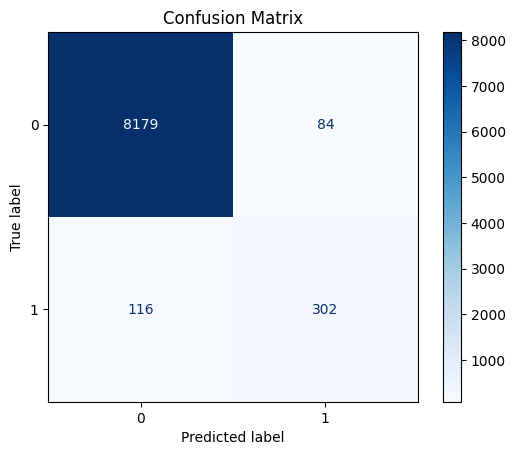

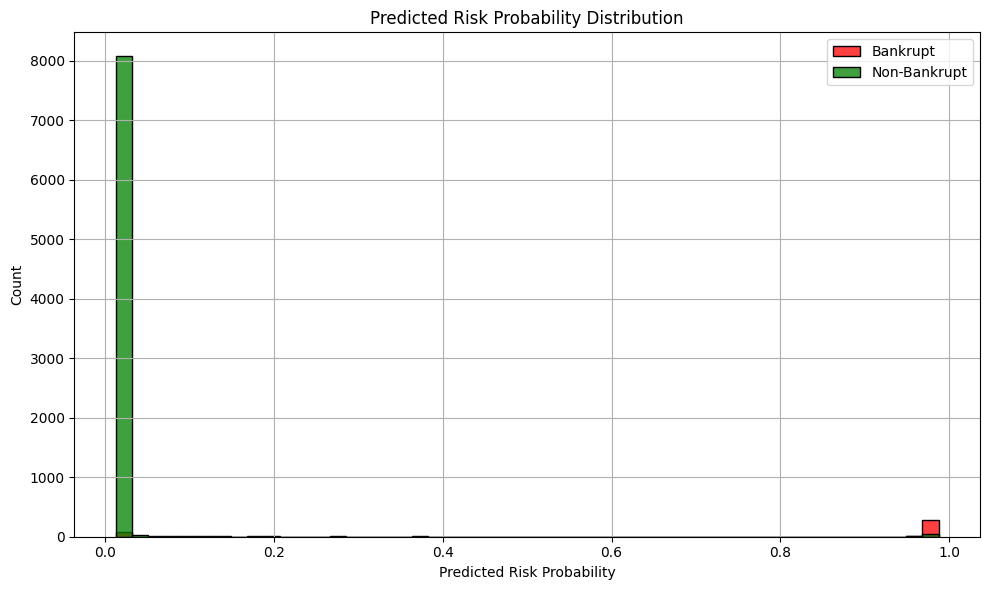

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8263
           1       0.78      0.72      0.75       418

    accuracy                           0.98      8681
   macro avg       0.88      0.86      0.87      8681
weighted avg       0.98      0.98      0.98      8681

📋 Classification Report for AutoGluon Model (ag_weighted_model):
              precision    recall  f1-score   support

           0     0.9860    0.9898    0.9879      8263
           1     0.7824    0.7225    0.7512       418

    accuracy                         0.9770      8681
   macro avg     0.8842    0.8562    0.8696      8681
weighted avg     0.9762    0.9770    0.9765      8681



In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split

# Load cleaned dataset
df = pd.read_csv("../datasets/processed/processed_polish_bankruptcy_data.csv")
df.columns = [col.replace("/", "_").replace(" ", "_").lower() for col in df.columns]

# Target column
target_col = "bankrupt"
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Load trained model
predictor = TabularPredictor.load("ag_weighted_model")

# Predictions
y_pred = predictor.predict(X_test)
y_proba = predictor.predict_proba(X_test)[1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Risk Probability Distribution
X_test["Actual"] = y_test
X_test["Predicted"] = y_pred
X_test["Risk_Probability"] = y_proba

plt.figure(figsize=(10, 6))
sns.histplot(X_test[X_test["Actual"] == 1]["Risk_Probability"], label="Bankrupt", color="red", kde=False, bins=50)
sns.histplot(X_test[X_test["Actual"] == 0]["Risk_Probability"], label="Non-Bankrupt", color="green", kde=False, bins=50)
plt.title("Predicted Risk Probability Distribution")
plt.xlabel("Predicted Risk Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Classification Report
print(classification_report(y_test, y_pred))

# Generate and print classification metrics for AutoGluon model
print("📋 Classification Report for AutoGluon Model (ag_weighted_model):")
print(classification_report(y_test, y_pred, digits=4))

# Save classification report as DataFrame
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("ag_weighted_model_classification_report.csv")
